<a href="https://colab.research.google.com/github/AmiraFaisal/ETEC2T/blob/main/dataLoad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# clone and download the GitHub repo only if it doesn't exist
import os
if not os.path.exists('/content/vistext'):
    !git clone https://github.com/mitvis/vistext.git
%cd /content/vistext

# remove existing data and images directories to avoid overwrite prompts
!rm -rf data
!rm -rf images

# download data
!bash download_data.sh --images

# move 'images' folder to the root only if it exists in data/ and not in root
if os.path.exists('data/images') and not os.path.exists('./images'):
    !mv data/images ./

# create target directory in Drive if it doesn't exist (mkdir -p handles existence)
!mkdir -p /content/drive/MyDrive/EvaltheEvaluators

# copy 'data' folder to Drive (images will be copied later based on selection)
!cp -r /content/vistext/data /content/drive/MyDrive/EvaltheEvaluators/

Streaming output truncated to the last 5000 lines.
  inflating: ./data/images/4439.png  
  inflating: ./data/images/444.png   
  inflating: ./data/images/4440.png  
  inflating: ./data/images/4441.png  
  inflating: ./data/images/4442.png  
  inflating: ./data/images/4443.png  
  inflating: ./data/images/4444.png  
  inflating: ./data/images/4445.png  
  inflating: ./data/images/4446.png  
  inflating: ./data/images/4447.png  
  inflating: ./data/images/4448.png  
  inflating: ./data/images/4449.png  
  inflating: ./data/images/445.png   
  inflating: ./data/images/4450.png  
  inflating: ./data/images/4451.png  
  inflating: ./data/images/4452.png  
  inflating: ./data/images/4453.png  
  inflating: ./data/images/4454.png  
  inflating: ./data/images/4455.png  
  inflating: ./data/images/4456.png  
  inflating: ./data/images/4457.png  
  inflating: ./data/images/4458.png  
  inflating: ./data/images/4459.png  
  inflating: ./data/images/446.png   
  inflating: ./data/images/4460.png  

Number of training samples: 9969 

Example entry at index 0:
{'L1_properties': ['line',
                   'National Football League average ticket price from 2006 to '
                   '2019 (in U.S. dollars)',
                   'Year',
                   'Ticket price in U.S. dollars',
                   'linear scale from 2006 to 2018',
                   'linear scale from 0 to 100'],
 'caption_L1': 'National Football League average ticket price from 2006 to '
               '2019 (in U.S. dollars) is a line chart. There is a linear '
               'scale from 2006 to 2018 along the x-axis, marked Year. Along '
               'the y-axis, Ticket price in U.S. dollars is measured along a '
               'linear scale from 0 to 100.',
 'caption_L2L3': 'The ticket price shown for 2006 is just over 60 dollars, and '
                 'it rises from that point to just over 100 dollars in 2018. '
                 'The line upward is quite steep, almost always rising sharply '
       

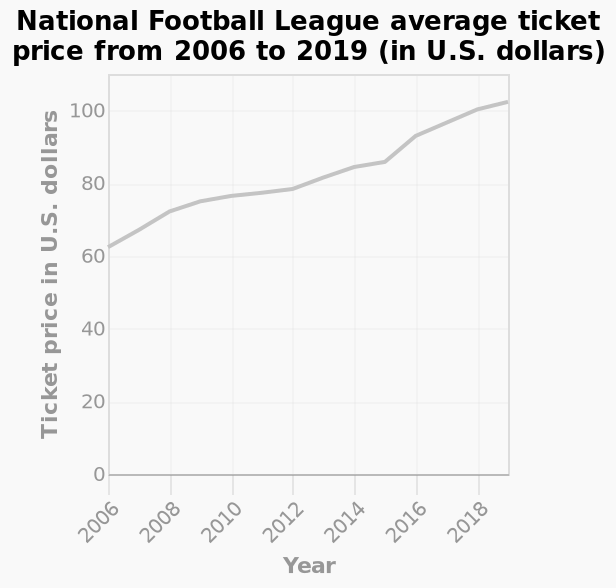

In [2]:
import json
import pprint
from IPython.display import Image, display
import os

# Ensure the current working directory is /content/vistext
os.chdir('/content/vistext')

with open("data/data_train.json") as f:
    data = json.load(f)

index = 0
print(f"Number of training samples: {len(data)} \n")
print(f"Example entry at index {index}:")
pprint.pprint(data[index])

# the relevant image
print("\n Chart:")
image_path = f'images/{index+1}.png'
display(Image(filename=image_path))

# Choosing 21 Representative Charts

In [3]:
import json
import pandas as pd

df = pd.DataFrame(data)

# create new column showing chart_type
# which can be extracted from column 'L1_properties'
df['chart_type'] = df['L1_properties'].apply(lambda x: x[0])
display(df['chart_type'].value_counts())

display(df)

,count
chart_type,
bar,4983
area,2563
line,2423


,caption_id,img_id,split,scenegraph,datatable,caption_L1,caption_L2L3,L1_properties,chart_type
0,1_01,1,train,title National Football League average ticket ...,National Football League average ticket price ...,National Football League average ticket price ...,The ticket price shown for 2006 is just over 6...,"[line, National Football League average ticket...",line
1,2_01,2,train,title Average viewers of Minecraft on Twitch w...,Average viewers of Minecraft on Twitch worldwi...,This is a area plot titled Average viewers of ...,Viewers of Minecraft on twitch has gradually i...,"[area, Average viewers of Minecraft on Twitch ...",area
2,2_02,2,train,title Average viewers of Minecraft on Twitch w...,Average viewers of Minecraft on Twitch worldwi...,This is a area plot titled Average viewers of ...,Minecraft viewing on Twitch sharply increased ...,"[area, Average viewers of Minecraft on Twitch ...",area
3,4_01,4,train,title Which of the following social and econom...,Which of the following social and economic iss...,This is a bar plot called Which of the followi...,The main issue is finding a job which would fi...,"[bar, Which of the following social and econom...",bar
4,5_01,5,train,title Share of prisoners under sentence of dea...,Share of prisoners under sentence of death in ...,This is a bar chart named Share of prisoners u...,Death rates have peaked in pensioners in the U...,"[bar, Share of prisoners under sentence of dea...",bar
...,...,...,...,...,...,...,...,...,...
9964,8820_01,8820,train,title Digital and print advertising revenue of...,Digital and print advertising revenue of U.S. ...,Digital and print advertising revenue of U.S. ...,In 2003 the digital and print advertising reve...,"[line, Digital and print advertising revenue o...",line
9965,8821_01,8821,train,title Digital and print advertising revenue of...,Digital and print advertising revenue of U.S. ...,Here a is a area graph called Digital and prin...,"As of 2004, the digital and printing advertisi...","[area, Digital and print advertising revenue o...",area
9966,8821_02,8821,train,title Digital and print advertising revenue of...,Digital and print advertising revenue of U.S. ...,Here a is a area graph called Digital and prin...,There is a gradual increase over the 8-year pe...,"[area, Digital and print advertising revenue o...",area
9967,8822_01,8822,train,title Number of passenger cars and commercial ...,Number of passenger cars and commercial vehicl...,Here a is a area chart labeled Number of passe...,The volume of users is consistently highThere...,"[area, Number of passenger cars and commercial...",area


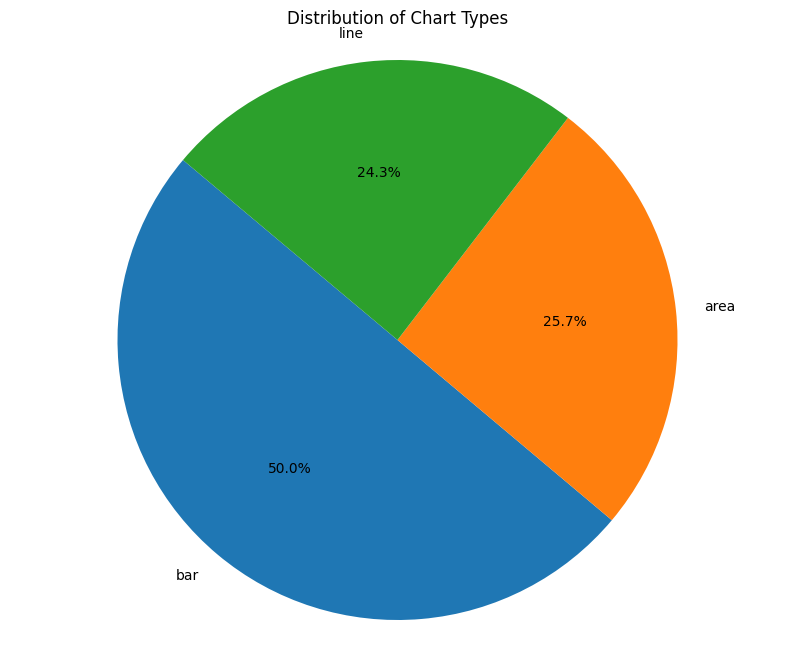

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
counts = df['chart_type'].value_counts()
plt.pie(counts,
        labels = counts.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title('Distribution of Chart Types')
plt.axis('equal')
plt.savefig('chart_type_distribution.png')
plt.show()

In [5]:
# dataframe of 21 charts (randomly selected, 3 of each chart type)
charts_df = df.set_index('chart_type').groupby(level='chart_type').apply(lambda x: x.sample(n=7, random_state=1))
charts_df = charts_df.reset_index(drop=True)
charts_df.to_csv('charts_df.csv', index=False)
# copy charts_df.csv to Google Drive
!cp -r /content/vistext/charts_df.csv /content/drive/MyDrive/EvaltheEvaluators/
display(charts_df.head(21))

,caption_id,img_id,split,scenegraph,datatable,caption_L1,caption_L2L3,L1_properties
0,3128_01,3128,train,title Armenia : Infant mortality rate from 200...,Armenia : Infant mortality rate from 2009 to 2...,This area chart is named Armenia : Infant mort...,There is a decline in infant deaths from 2010 ...,"[area, Armenia : Infant mortality rate from 20..."
1,2114_01,2114,train,title Iran : Youth unemployment rate from 1999...,Iran : Youth unemployment rate from 1999 to 20...,Here a is a area chart titled Iran : Youth une...,"Youth unemployment was better in 2004,and incr...","[area, Iran : Youth unemployment rate from 199..."
2,2472_03,2472,train,title Net profit of the Agricultural Bank of C...,Net profit of the Agricultural Bank of China f...,Here a is a area chart titled Net profit of th...,The net profit has continued to increase each ...,"[area, Net profit of the Agricultural Bank of ..."
3,8673_01,8673,train,title Cambodia : Share of economic sectors in ...,Cambodia : Share of economic sectors in the gr...,This area chart is called Cambodia : Share of ...,From the graph it can be seen that there is a ...,"[area, Cambodia : Share of economic sectors in..."
4,1356_04,1356,train,title Number of house fires caused by burning ...,Number of house fires caused by burning Christ...,This is a area plot named Number of house fire...,The general trend shows a reduction in fires s...,"[area, Number of house fires caused by burning..."
5,1061_02,1061,train,title Gazprom 's natural and associated gas pr...,Gazprom 's natural and associated gas producti...,This area chart is named Gazprom 's natural an...,Gazprom's production of natural and associated...,"[area, Gazprom 's natural and associated gas p..."
6,2121_01,2121,train,title American customer satisfaction index sco...,American customer satisfaction index scores of...,Here a is a area chart titled American custome...,"Between the years 2010 and 2015, we observed t...","[area, American customer satisfaction index sc..."
7,8038_01,8038,train,title How often do you use various hygienic pr...,How often do you use various hygienic products...,Here a is a bar diagram labeled How often do y...,"Facial mask is used the most, where as toothpa...","[bar, How often do you use various hygienic pr..."
8,4915_02,4915,train,title Revenue of the Charlotte Hornets from 20...,Revenue of the Charlotte Hornets from 2004/05 ...,Revenue of the Charlotte Hornets from 2004/05 ...,Apart from a slight dip in 11/12 the revenue h...,"[bar, Revenue of the Charlotte Hornets from 20..."
9,7567_01,7567,train,title Distribution of leading causes of neonat...,Distribution of leading causes of neonatal dea...,This bar chart is labeled Distribution of lead...,The chart shows that the leading causes of neo...,"[bar, Distribution of leading causes of neonat..."


In [6]:
import os
import shutil

drive_target_path = '/content/drive/MyDrive/EvaltheEvaluators'

# Create a subdirectory for selected images if it doesn't exist
selected_images_dir = os.path.join(drive_target_path, 'selected_images')
!mkdir -p "{selected_images_dir}"

print(f"Copying {len(charts_df)} selected images to Drive...")
for img_id in charts_df['img_id']:
    src_path = f'images/{img_id}.png'
    dst_path = os.path.join(selected_images_dir, f'{img_id}.png')
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
    else:
        print(f"Warning: Image {src_path} not found.")

print(f"Checking contents of {drive_target_path}:")
if os.path.exists(drive_target_path):
    for item in os.listdir(drive_target_path):
        print(item)
else:
    print(f"The directory {drive_target_path} does not exist in this Colab session.")

Copying 21 selected images to Drive...
Checking contents of /content/drive/MyDrive/EvaltheEvaluators:
load1.ipynb
data
charts_df.csv
vistext
images
ChartGemma_Model
Qwen_Model
evaluations
selected_images


Number of charts: 21 



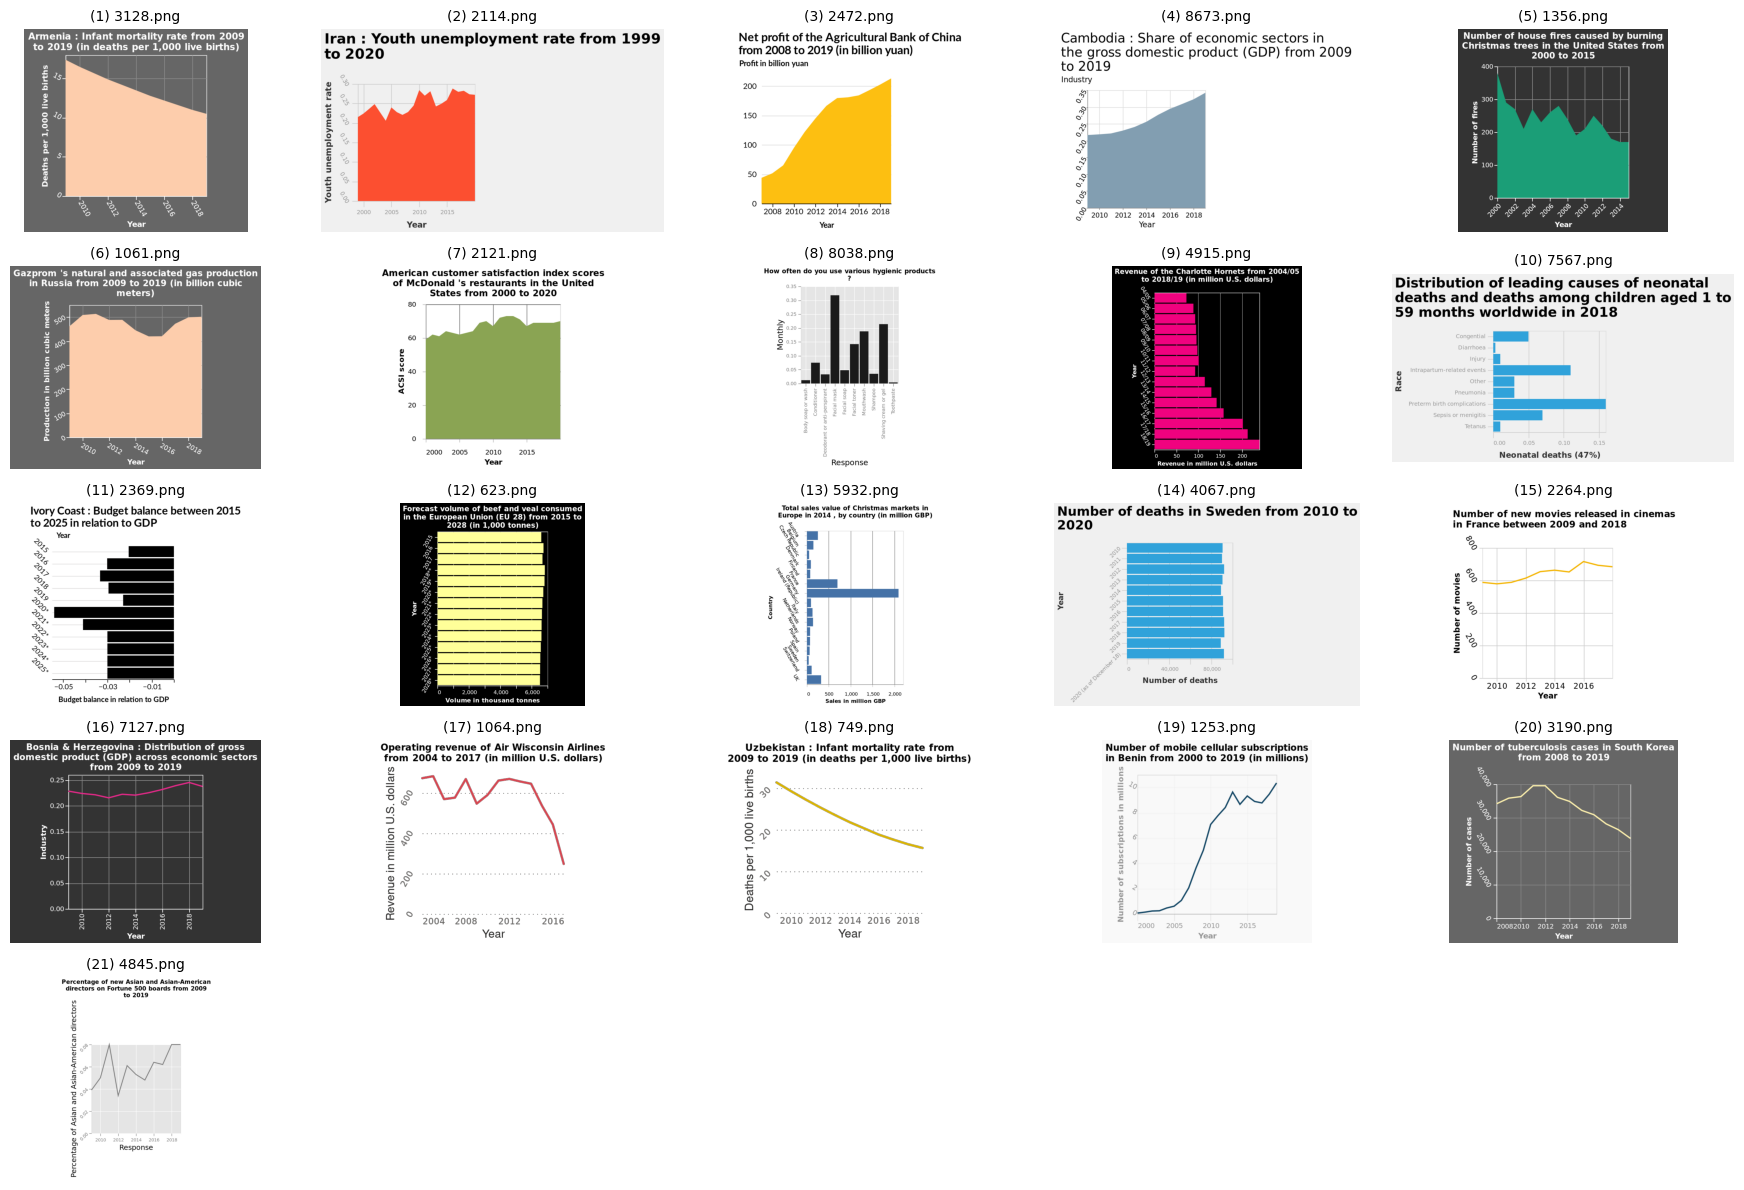

In [7]:
import matplotlib.pyplot as plt
from IPython.display import Image
import os

# Flatten to 1D array for easier indexing
fig, axes = plt.subplots(5, 5, figsize=(18, 12))
axes = axes.flatten()

print(f"Number of charts: {len(charts_df)} \n")

# Plot each chart
for idx, id in enumerate(charts_df['img_id']):
    image_path = f'images/{id}.png'

    if os.path.exists(image_path):
        img = plt.imread(image_path)
        axes[idx].imshow(img)
        title = f"({idx+1}) {id}.png"
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')  # Hide axes
    else:
        axes[idx].text(0.5, 0.5, f'Image not found\n{id}',
                       ha='center', va='center')
        axes[idx].axis('off')

# Hide any unused subplots
for idx in range(len(charts_df), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [8]:
import os
import shutil

drive_target_path = '/content/drive/MyDrive/EvaltheEvaluators'
selected_images_dir = os.path.join(drive_target_path, 'images')

print(f"Clearing existing contents of '{drive_target_path}' in Drive (if any).")
# Remove all contents within the target Drive folder
!rm -rf "{drive_target_path}"/*

# Ensure the base directory exists after clearing
!mkdir -p "{drive_target_path}"

# Create the images subdirectory for selected content
!mkdir -p "{selected_images_dir}"

print(f"Copying charts_df.csv to '{drive_target_path}'...")
charts_df_src = 'charts_df.csv'
charts_df_dst = os.path.join(drive_target_path, 'charts_df.csv')
if os.path.exists(charts_df_src):
    shutil.copy(charts_df_src, charts_df_dst)
else:
    print(f"Warning: {charts_df_src} not found.")

print(f"Copying L2L3_captions.json to '{selected_images_dir}'...")
json_src_path = 'data/L2L3_captions.json'
json_dst_path = os.path.join(selected_images_dir, 'L2L3_captions.json')
if os.path.exists(json_src_path):
    shutil.copy(json_src_path, json_dst_path)
else:
    print(f"Warning: {json_src_path} not found.")

print(f"Copying {len(charts_df)} selected images to '{selected_images_dir}'...")
for img_id in charts_df['img_id']:
    src_path = f'images/{img_id}.png'
    dst_path = os.path.join(selected_images_dir, f'{img_id}.png')
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
    else:
        print(f"Warning: Image {src_path} not found.")

print(f"Checking contents of {drive_target_path}:")
if os.path.exists(drive_target_path):
    for item in os.listdir(drive_target_path):
        print(item)
else:
    print(f"The directory {drive_target_path} does not exist in this Colab session.")

Clearing existing contents of '/content/drive/MyDrive/EvaltheEvaluators' in Drive (if any).
Copying charts_df.csv to '/content/drive/MyDrive/EvaltheEvaluators'...
Copying L2L3_captions.json to '/content/drive/MyDrive/EvaltheEvaluators/images'...
Copying 21 selected images to '/content/drive/MyDrive/EvaltheEvaluators/images'...
Checking contents of /content/drive/MyDrive/EvaltheEvaluators:
charts_df.csv
images
